# 02 — Download and Clip DEM

Download a USGS 1m Digital Elevation Model for the Big Island and clip it to the
Kona Coffee Belt study area.

**DEM source:** USGS 3DEP 1-meter program via the TNM S3 bucket.

Steps:
1. Find the DEM tile(s) covering the Kona region at https://apps.nationalmap.gov/downloader/
   (filter: Elevation Products → 1 meter DEM → Hawaii)
2. Paste the `.tif` download URL(s) into `DEM_LINKS` below.
3. Run notebook — merges tiles, reprojects to UTM, clips to region, saves:
   - `../data/DEM/kona_DEM_utm.tif`   — UTM (meters) for feature computation
   - `../data/DEM/kona_DEM_latlon.tif` — WGS-84 for plotting

> If the study area spans multiple 1m tiles, list all URLs; the notebook will mosaic them.

In [1]:
import os
import requests
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.merge import merge
from rasterio.warp import calculate_default_transform, reproject, Resampling
import json
from tqdm import tqdm

UTM_CRS  = 'EPSG:32604'
NODATA   = -9999.0
DEM_DIR  = '../data/DEM'
os.makedirs(DEM_DIR, exist_ok=True)

# ── Paste 1m DEM tile URLs here ────────────────────────────────────────────
# Find at: https://apps.nationalmap.gov/downloader/
# Filter: Elevation Products (3DEP) → 1 meter DEM → Hawaii → Big Island
DEM_LINKS = [
    'https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/13/TIFF/historical/n20w156/USGS_13_n20w156_20250611.tif'
    # Example (replace with real URLs from TNM downloader):
    # 'https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/1m/Projects/HI_BigIsland_2021/TIFF/USGS_1M_...tif',
]

# ── Alternative: 10m NED (always available) ─────────────────────────────────
# If 1m tiles are unavailable or the region is too large, use the 10m NED.
# Download the 1x1 degree tile for 20N 156W from:
# https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/13/TIFF/n20w156/USGS_13_n20w156.tif
# (resolution 1/3 arc-second ≈ 10m at this latitude)
NED_10M_URL = 'https://prd-tnm.s3.amazonaws.com/StagedProducts/Elevation/13/TIFF/n20w156/USGS_13_n20w156.tif'

USE_10M_FALLBACK = len(DEM_LINKS) == 0  # True if no 1m URLs provided
if USE_10M_FALLBACK:
    DEM_LINKS = [NED_10M_URL]
    print('No 1m URLs provided — using 10m NED fallback.')


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/_compat.py:115: UserWarning: The Shapely GEOS version (3.11.4-CAPI-1.17.4) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  shapely_geos_version, geos_capi_version_string


In [2]:
def download_file(url: str, dest: str):
    if os.path.exists(dest):
        print(f'Already exists: {dest}')
        return
    print(f'Downloading → {dest}')
    r = requests.get(url, stream=True)
    r.raise_for_status()
    total = int(r.headers.get('content-length', 0))
    with open(dest, 'wb') as f, tqdm(total=total, unit='iB', unit_scale=True) as bar:
        for chunk in r.iter_content(1024):
            bar.update(len(chunk))
            f.write(chunk)
    print('Done.')


raw_paths = []
for i, url in enumerate(DEM_LINKS):
    fname = os.path.join(DEM_DIR, f'kona_DEM_raw_{i}.tif')
    download_file(url, fname)
    raw_paths.append(fname)

print(f'Downloaded {len(raw_paths)} tile(s).')

Already exists: ../data/DEM/kona_DEM_raw_0.tif
Downloaded 1 tile(s).


In [3]:
# Load region polygon for clipping
region = gpd.read_file('../data/polygons/kona_region.geojson')
region_utm = region.to_crs(UTM_CRS)

print('Region CRS:', region.crs)
print('Bounds:', region.total_bounds)

Region CRS: epsg:4326
Bounds: [-156.00499011   19.04252317 -155.4377909    19.75791487]


In [4]:
# ── Mosaic tiles if >1, then reproject to UTM ───────────────────────────────
mosaic_path = os.path.join(DEM_DIR, 'kona_DEM_mosaic.tif')

if len(raw_paths) == 1:
    mosaic_path = raw_paths[0]  # no mosaic needed
else:
    srcs = [rasterio.open(p) for p in raw_paths]
    mosaic, out_transform = merge(srcs)
    out_meta = srcs[0].meta.copy()
    out_meta.update({'height': mosaic.shape[1], 'width': mosaic.shape[2],
                     'transform': out_transform})
    with rasterio.open(mosaic_path, 'w', **out_meta) as dst:
        dst.write(mosaic)
    for s in srcs:
        s.close()
    print(f'Mosaic saved: {mosaic_path}')

# Inspect raw tile
with rasterio.open(mosaic_path) as src:
    print('Source CRS:   ', src.crs)
    print('Source bounds:', src.bounds)
    print('Source res:   ', src.res)

Source CRS:    EPSG:4269
Source bounds: BoundingBox(left=-156.00055555639332, bottom=18.999444443706977, right=-154.99944444420524, top=20.000555555895062)
Source res:    (9.259259269220167e-05, 9.259259269220167e-05)


In [5]:
# ── Reproject to UTM (meters) ───────────────────────────────────────────────
utm_path = os.path.join(DEM_DIR, 'kona_DEM_utm_full.tif')

with rasterio.open(mosaic_path) as src:
    transform, width, height = calculate_default_transform(
        src.crs, UTM_CRS, src.width, src.height, *src.bounds
    )
    kwargs = src.meta.copy()
    kwargs.update({'crs': UTM_CRS, 'transform': transform,
                   'width': width, 'height': height,
                   'dtype': 'float32', 'nodata': NODATA})

    with rasterio.open(utm_path, 'w', **kwargs) as dst:
        for i in range(1, src.count + 1):
            reproject(
                source=rasterio.band(src, i),
                destination=rasterio.band(dst, i),
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=UTM_CRS,
                resampling=Resampling.bilinear
            )

print(f'Reprojected UTM DEM: {utm_path}')

Reprojected UTM DEM: ../data/DEM/kona_DEM_utm_full.tif


In [6]:
# ── Clip to Kona region ─────────────────────────────────────────────────────
geoms = [json.loads(region_utm.to_json())['features'][0]['geometry']]

with rasterio.open(utm_path) as src:
    dem_clip, clip_transform = mask(src, geoms, crop=True, filled=True, nodata=NODATA)
    dem_clip = dem_clip.astype('float32')
    clip_meta = src.meta.copy()
    clip_meta.update({
        'height': dem_clip.shape[1], 'width': dem_clip.shape[2],
        'transform': clip_transform, 'nodata': NODATA
    })

utm_clip_path = os.path.join(DEM_DIR, 'kona_DEM_utm.tif')
with rasterio.open(utm_clip_path, 'w', **clip_meta) as dst:
    dst.write(dem_clip)

print(f'Clipped UTM DEM saved: {utm_clip_path}')
print(f'Shape: {dem_clip.shape},  nodata={NODATA}')

Clipped UTM DEM saved: ../data/DEM/kona_DEM_utm.tif
Shape: (1, 7849, 6066),  nodata=-9999.0


In [7]:
# ── Also save lat/lon version for plotting ──────────────────────────────────
latlon_path = os.path.join(DEM_DIR, 'kona_DEM_latlon.tif')

with rasterio.open(utm_clip_path) as src:
    transform_ll, w_ll, h_ll = calculate_default_transform(
        src.crs, 'EPSG:4326', src.width, src.height, *src.bounds
    )
    kwargs_ll = src.meta.copy()
    kwargs_ll.update({'crs': 'EPSG:4326', 'transform': transform_ll,
                      'width': w_ll, 'height': h_ll})
    reproj_ll = np.empty((src.count, h_ll, w_ll), dtype='float32')
    for i in range(1, src.count + 1):
        reproject(
            source=rasterio.band(src, i),
            destination=reproj_ll[i - 1],
            src_transform=src.transform, src_crs=src.crs,
            dst_transform=transform_ll, dst_crs='EPSG:4326',
            resampling=Resampling.bilinear
        )
    with rasterio.open(latlon_path, 'w', **kwargs_ll) as dst:
        dst.write(reproj_ll)

print(f'Lat/lon DEM saved: {latlon_path}')

Lat/lon DEM saved: ../data/DEM/kona_DEM_latlon.tif


/home/simonhans/anaconda3/lib/python3.7/site-packages/geopandas/plotting.py:51: ShapelyDeprecationWarning: The 'type' attribute is deprecated, and will be removed in the future. You can use the 'geom_type' attribute instead.
  if geom is not None and geom.type.startswith(prefix) and not geom.is_empty:


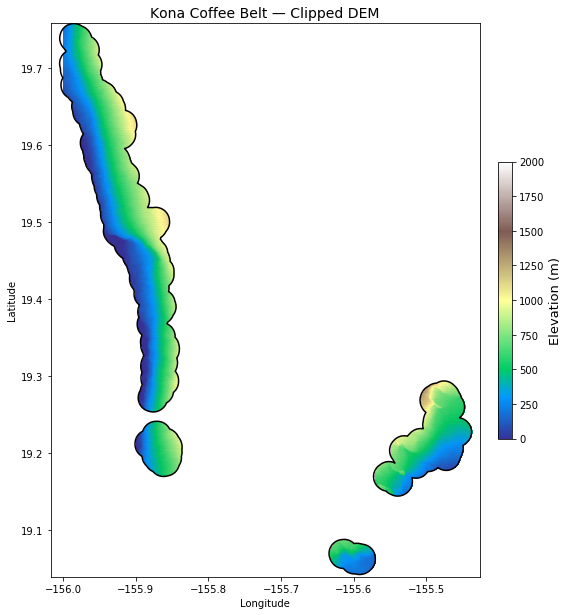

In [9]:
# ── Visualize ───────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import pandas as pd
with rasterio.open(latlon_path) as src:
    dem_vis = src.read(1, masked=True)
    extent  = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

region_ll = region.to_crs('EPSG:4326')
grid = pd.read_pickle('../data/polygons/kona_grid.pkl')

fig, ax = plt.subplots(figsize=(8, 10))
im = ax.imshow(dem_vis, extent=extent, origin='upper', cmap='terrain',
               vmin=0, vmax=2000)
cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('Elevation (m)', fontsize=13)
region_ll.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)
grid.plot(ax=ax, facecolor='none', edgecolor='red', linewidth=0.02, alpha=0.5)
ax.set_title('Kona Coffee Belt — Clipped DEM', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('../img/02_dem_clip.png', dpi=150)
plt.show()